# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [1]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt
import numpy as np


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [2]:
# Load data
data = pd.read_csv('data/bcn_noise_ml_dataset.csv')
print(data)

                       road_id  noise_day  noise_evening  noise_night  \
0      13845167536_847716886_0         55             55           50   
1          21638869_30343583_0         55             50           50   
2         21638869_242318729_0         55             55           50   
3          21638869_30343672_0         60             60           55   
4       3055187877_431100338_0         60             60           55   
...                        ...        ...            ...          ...   
11664  2239783361_4577282718_0         60             60           55   
11665   2239783361_885307899_0         60             60           55   
11666   885307964_4577282718_0         60             60           55   
11667    885307964_885307899_0         60             60           55   
11668    885307899_885307964_0         60             60           55   

       road_length  road_category  dist_to_main  signals  transport   pois  \
0          401.484              5       258.6

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11669 entries, 0 to 11668
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          11669 non-null  str    
 1   noise_day        11669 non-null  int64  
 2   noise_evening    11669 non-null  int64  
 3   noise_night      11669 non-null  int64  
 4   road_length      11669 non-null  float64
 5   road_category    11669 non-null  int64  
 6   dist_to_main     11669 non-null  float64
 7   signals          11669 non-null  float64
 8   transport        11669 non-null  float64
 9   pois             11669 non-null  float64
 10  width            11669 non-null  float64
 11  betw_centrality  11669 non-null  float64
 12  clos_centrality  11669 non-null  float64
dtypes: float64(8), int64(4), str(1)
memory usage: 1.2 MB


## Predicting the Nomad Score


Prepare data

In [4]:
# Select the (independant) features that we are going to use to train the model
X = data.drop(columns=['road_id', 'road_length','noise_day','noise_evening', 'noise_night']) # keep only features
X

,road_category,dist_to_main,signals,transport,pois,width,betw_centrality,clos_centrality
0,5,258.681,0.249,2.491,0.747,16.759,0.004,0.000
1,5,429.190,1.106,3.319,25.000,7.973,0.000,0.000
2,4,512.334,6.655,10.000,25.000,17.914,0.001,0.000
3,4,516.423,6.504,10.000,25.000,18.217,0.002,0.000
4,5,214.042,2.170,4.340,2.170,16.532,0.007,0.000
...,...,...,...,...,...,...,...,...
11664,5,750.000,15.000,9.712,6.475,50.000,0.000,0.000
11665,5,750.000,4.466,2.680,1.786,42.857,0.000,0.000
11666,5,750.000,4.445,2.667,1.778,50.000,0.000,0.000
11667,5,750.000,3.723,7.446,3.723,50.000,0.000,0.000


In [5]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

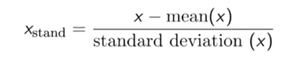

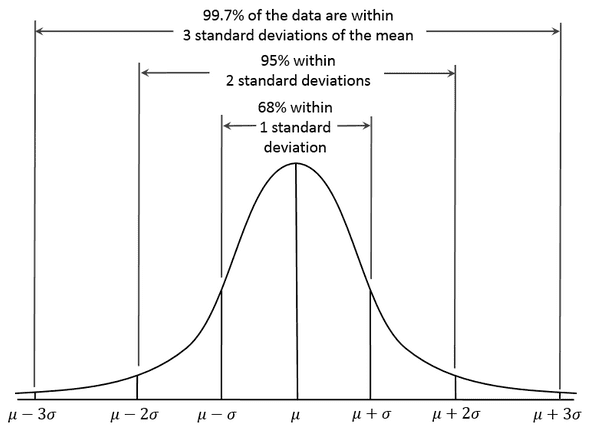

In [6]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.3760568 ,  0.50288884, -0.9794011 , ..., -0.82737206,
        -0.02617757,  0.8461456 ],
       [ 0.3760568 ,  1.44856467, -0.79512402, ..., -1.43258097,
        -0.53352738, -0.49988559],
       [-0.60608439,  1.90969272,  0.39782236, ..., -0.74785929,
        -0.41953728, -0.51840526],
       ...,
       [ 0.3760568 ,  3.22783283, -0.07735951, ...,  1.46219983,
        -0.51012151, -1.18775564],
       [ 0.3760568 ,  3.22783283, -0.23253368, ...,  1.46219983,
        -0.53591308, -1.21730909],
       [ 0.3760568 ,  3.22783283, -0.62653823, ...,  1.46219983,
        -0.53591308, -1.21730909]], shape=(11669, 8))

In [7]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(11669, 8)
              0         1         2         3         4         5         6  \
count 11669.000 11669.000 11669.000 11669.000 11669.000 11669.000 11669.000   
mean      0.000    -0.000    -0.000    -0.000     0.000     0.000    -0.000   
std       1.000     1.000     1.000     1.000     1.000     1.000     1.000   
min      -3.553    -0.932    -1.026    -1.627    -0.932    -1.982    -0.536   
25%      -0.606    -0.932    -0.746    -0.852    -0.766    -0.856    -0.508   
50%       0.376    -0.263    -0.402    -0.284    -0.452    -0.091    -0.406   
75%       0.376     0.556     0.395     0.971     0.452     0.887    -0.017   
max       1.358     3.228     2.192     1.530     2.116     1.462     9.805   

              7  
count 11669.000  
mean     -0.000  
std       1.000  
min      -3.246  
25%      -0.523  
50%       0.049  
75%       0.740  
max       1.622  


In [8]:
# Define the dependant variable / target to predict
y_reg = data.noise_day
print(y_reg)

0        55
1        55
2        55
3        60
4        60
         ..
11664    60
11665    60
11666    60
11667    60
11668    60
Name: noise_day, Length: 11669, dtype: int64


In [9]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [10]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(9335, 8)
(9335,)
(2334, 8)
(2334,)


Train model

In [11]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.3884324923553222
0.3847798483276941


In [12]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [-1.61009726 -1.51201725  0.99646202 -0.29320108  0.21699616  0.63336356
  0.53097424  2.08346934] intercetp 59.704280435436374


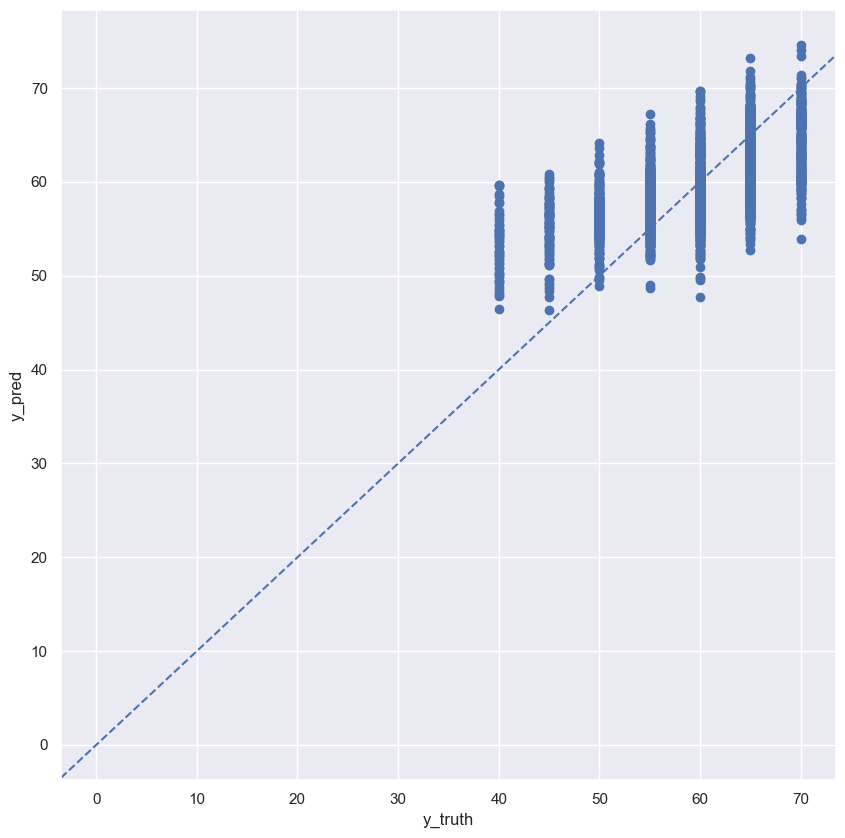

In [13]:
# We can also inspect our results visually
y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [14]:
data_test.info()

<class 'pandas.DataFrame'>
Index: 2334 entries, 11292 to 5651
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   road_id          2334 non-null   str    
 1   noise_day        2334 non-null   int64  
 2   noise_evening    2334 non-null   int64  
 3   noise_night      2334 non-null   int64  
 4   road_length      2334 non-null   float64
 5   road_category    2334 non-null   int64  
 6   dist_to_main     2334 non-null   float64
 7   signals          2334 non-null   float64
 8   transport        2334 non-null   float64
 9   pois             2334 non-null   float64
 10  width            2334 non-null   float64
 11  betw_centrality  2334 non-null   float64
 12  clos_centrality  2334 non-null   float64
dtypes: float64(8), int64(4), str(1)
memory usage: 255.3 KB


In [15]:
data_test['noisePred_reg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_reg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main', 'signals']
).interactive()

alt.Chart(...)

## XGBoost

Let's try a different model class

In [16]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.8581364154815674
0.5354335308074951


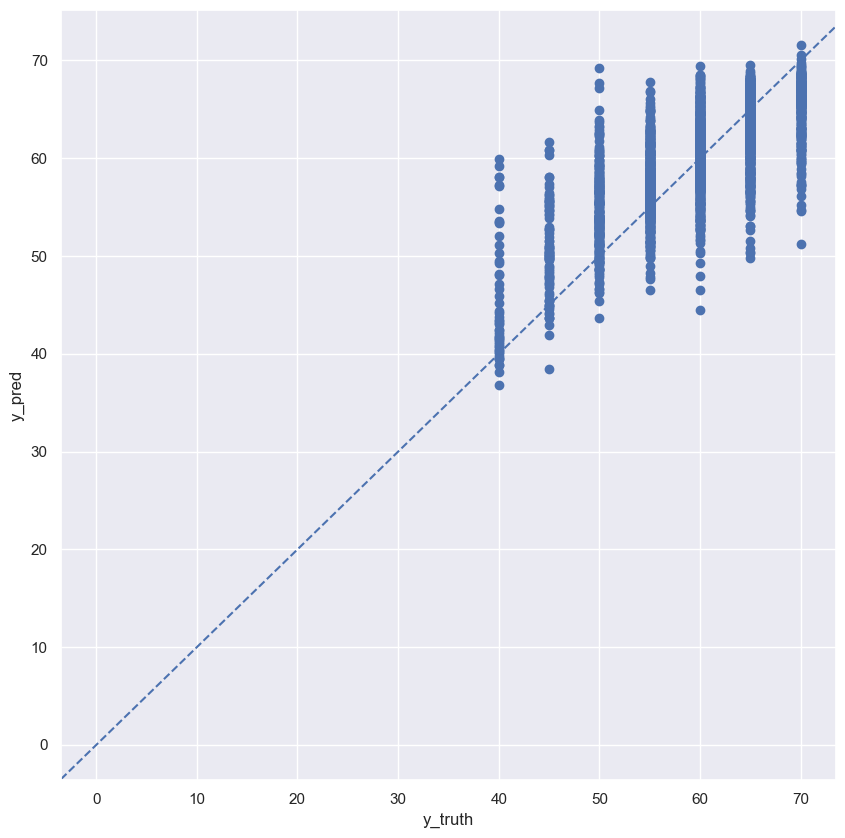

In [17]:
# We can also inspect our results visually
y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.axline((0,0), slope = 1, ls="--")

In [18]:
data_test['noisePred_xg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='noise_day',
    y='noisePred_xg',
    color=alt.Color('road_category', scale=alt.Scale(scheme='category10')),
    tooltip=['dist_to_main','signals']
).interactive()

alt.Chart(...)

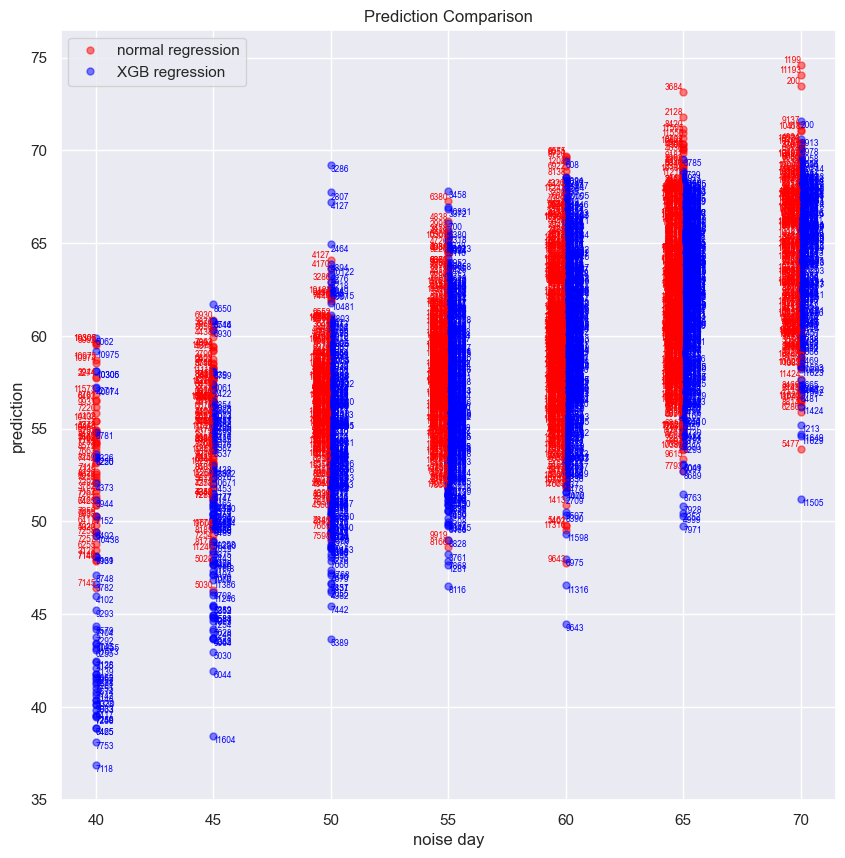

In [19]:
# Comparative plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_reg"],
    color="red",
    label="normal regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha = 0.5
)

ax1.plot(
    data_test["noise_day"],
    data_test["noisePred_xg"],
    color="blue",
    label="XGB regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha=0.5
)

# Labels for red points (normal regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_reg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='right', va='bottom', color="red")

# Labels for blue points (XGB regression)
for idx, (x, y) in data_test[["noise_day", "noisePred_xg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='left', va='top', color="blue")

ax1.set_xlabel('noise day')
ax1.set_ylabel('prediction')
ax1.legend()

plt.title('Prediction Comparison')
plt.show()